In [242]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import random
from qiskit.quantum_info import random_clifford, random_pauli, entropy, Clifford
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
import matplotlib.pyplot as plt
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [243]:
gate = random_clifford(2, seed=None,)
depolarizingchannel = random_clifford(1, seed=None)

def random_depolarizing_channel(L, t):
    for t in range(4):
        for i in range(L):
            circuit.unitary(depolarizingchannel, [i], label="dp")

circuit = QuantumCircuit(2, 4)

random_depolarizing_channel(2, 4)
circuit.measure_all()

p_replace = 4/3
error_replace = depolarizing_error(p_replace, 1)
noise = NoiseModel()
noise.add_all_qubit_quantum_error(error_replace, ["u1", "u2", "u3"])

sim_noise = AerSimulator(noise_model=noise)

passmanager = generate_preset_pass_manager(
    optimization_level=3, backend=sim_noise
)
circ_tnoise = passmanager.run(circuit)

In [244]:
print(noise)

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'u1', 'u2', 'u3']
  Instructions with noise: ['u2', 'u3', 'u1']
  All-qubits errors: ['u1', 'u2', 'u3']


In [245]:
print(error_replace)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.3333333333333333, Circuit = 
   ┌───┐
q: ┤ X ├
   └───┘
  P(1) = 0.3333333333333333, Circuit = 
   ┌───┐
q: ┤ Y ├
   └───┘
  P(2) = 0.3333333333333333, Circuit = 
   ┌───┐
q: ┤ Z ├
   └───┘


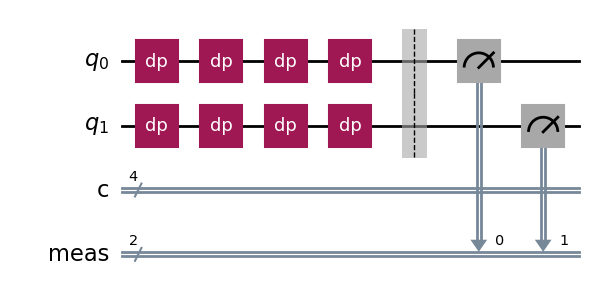

In [246]:
circuit.draw("mpl")

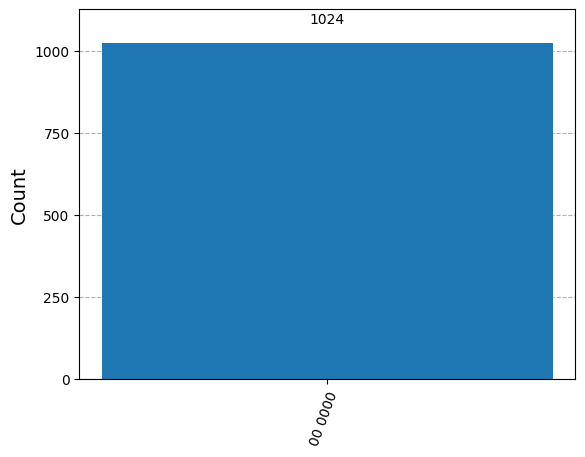

In [247]:
result_bit_flip = sim_noise.run(circ_tnoise).result()
counts_bit_flip = result_bit_flip.get_counts(0)

plot_histogram(counts_bit_flip)